# Evolution Guide (Tao et al. 2026, in prep)
### AKA: How to use our Steam World Evolution Model!

This notebook* walks you through how to use the **steam world evolution code** of Tao et al. 2026 (in prep) so you can run your own evolutions of simulated steam worlds!

Please don't hesitate to reach out to extao@ucsc.edu if you have any questions.

Sections you can customize will look as follows:

```
#--------- CUSTOMIZE HERE ---------#
variable = value you can modify
#----------------------------------#
```

_*This notebook performs the same functions as xp_evolution.py_

## I. Setup
Run through this section first to load in modules and constants

In [1]:
import os, sys
sys.path.insert(0, 'Models')
import xpml
import numpy as np
import multiprocessing

# Constants and Units
M_e   = 5.972e24  #Earth mass (kg)
R_e   = 6.371e6   #Earth radius (m)

M_sun = 1.988e30  #Solar mass (kg)
R_sun = 6.955e10  #Solar radius (m)
L_sun = 3.828e26  #luminosity of the Sun (Watts, kg⋅m^2⋅s^-3)

Fuv_e = 4.667     #W/m^2
au    = 1.496e11  #astronomical unit (m)
Gyr   = 3.153e16  #seconds in 1 billion years
G     = 6.674e-11 #gravitational constant (m^3⋅kg^-1⋅s^-2)
sigma_sb = 5.670374419e-8 #W⋅m−2⋅K−4 ; Stefan-Boltzmann constant

### I. a. Parallelization

The evolution code can be parallelized to simultaneously evolve steam worlds. 

You can manually determine how many CPU's you would like to use, or use the default (half of your device's CPUs).

In [2]:
cpu_ct = multiprocessing.cpu_count()
cpu_default = int(cpu_ct)/2

#--------- CUSTOMIZE HERE ---------#
cores = cpu_default
#----------------------------------#

print(f'\nCores in use: {int(cores)}/{cpu_ct}')


Cores in use: 4/8


## II. Population

This paper does **_NOT_** model population synthesis. This is a randomly generated sample of planets with steam world properties to span a wide range of possibilities.

You can either **GENERATE** a new population or **LOAD** an existing population.
In this GitHub repository, we provide starting data, but you can also create your own.

Population starting files:
* `{n_planets}_xp_gp_data.csv` : Initial parameters for `n_planets` sub-Neptune steam worlds in MKS units.
* `{n_planets}_xp_gp_data_unitEarth.csv` : Same initial parameters, but in Earth and astronomical units. (example: au, M_Earth)

### II. a. GENERATE a population

You can customize how many planets you want to simulate evolution for and where to save the data.

If enabled (default), the planet generator will print a truncated table of values. You can view the full output file in `{savepath}/{n_planets}_xp/`. The `_unitEarth` version may be more reader-friendly.

_Output header: planetnum, mp_gp, rp_gp, mcore_gp, rsurf_gp, teq_gp, wmf_gp, grav_gp, H_gp, lambda_gp, sep_gp, period_gp, startype_gp, mstar_gp, lstar_gp, fxuv_gp_

In [3]:
n_planets_default = 200

#------- CUSTOMIZE HERE ---------#
n_planets = n_planets_default
datapath = './data/'                # A save folder will be created (if it doesn't already exist) named '{n_planets}_xp'
printtable= True                    # Set to False to disable printing a table of the generated population's values
#--------------------------------#

OUTPUT = xpml.planet_generator(n_planets, savepath=datapath, printtable=printtable)
planetnum, mp_gp, rp_gp, teq_gp, wmf_gp = OUTPUT[0], OUTPUT[1], OUTPUT[2], OUTPUT[5], OUTPUT[6]
sep_gp, mstar_gp, lstar_gp = OUTPUT[11], OUTPUT[13], OUTPUT[14]


200 planets generated.
Directory '200_xp' already exists in ./data/. WARNING: Data in this folder will be overwritten.

PLANET POPULATION INFORMATION
Number Mass (M𛲜) Radius (R𛲜) ... Lstar (L☉) Mstar (M☉) Fxuv (W/m^2)
------ --------- ----------- ... ---------- ---------- ------------
     1     1.862       2.175 ...      0.037      0.451      772.609
     2     3.784       2.572 ...      0.050      0.514      658.541
     3     5.877       2.466 ...      0.001      0.168     1153.629
     4     4.418       2.656 ...      0.013      0.339     3997.223
     5     2.621       2.249 ...      0.008      0.299     1013.529
     6     7.041       2.320 ...      0.123      0.761      142.947
     7     8.975       2.705 ...      0.000      0.080     5145.218
     8    14.625       2.522 ...      0.001      0.172     1068.659
     9     2.088       1.530 ...      0.134      0.791     1180.185
    10    13.899       2.501 ...      0.041      0.472     2452.649
   ...       ...         ... ... 

### II. b. IMPORT a population

Currently only accepts the format provided by xpml's planet_generator() function.

In [4]:
n_planets_default = 5000

#------- CUSTOMIZE HERE ---------#
n_planets = 200
savepath = datapath + f'{n_planets}_xp/'     # Modification is not recommended and should not be needed.
#--------------------------------#

init_data_csv = savepath + f'{n_planets}_xp_gp_data.csv'

OUTPUT = np.loadtxt(fname=init_data_csv,skiprows=(1), unpack=True)
planetnum, mp_gp, rp_gp = OUTPUT[0], OUTPUT[1], OUTPUT[2]

## III. Choose Escape Type
Choose whether you want to run for H2O mass-loss rates, H-He mass-loss rates, or both. The default is **H2O only**.

In [5]:
#------- CUSTOMIZE HERE ---------#
run_H2O = True
run_HHe = False
#--------------------------------#

if run_H2O and run_HHe:
    mdot_type = ['H2O', 'H-He']
    print("Running both H2O and H-He simulations.")
elif run_H2O and not run_HHe:
    mdot_type = ['H2O']
    print("Running H2O simulations only.")
elif run_HHe and not run_H2O:
    mdot_type = ['H-He']
    print("Running H-He simulations only.")

Running H2O simulations only.


In [6]:
# Create directories for each mass-loss rate type specified in mdot_type
for mt in mdot_type:
    location = savepath + f"{mt}/"
    try:
        os.mkdir(location)
        print(f"Directory '{mt}' created successfully in {savepath}.")
    except FileExistsError:
        print(f"Directory '{mt}' already exists in {savepath}.")
    except Exception as e:
        print(f"An error occurred: {e}")

Directory 'H2O' already exists in ./data/200_xp/.


## IV. Run Evolution

Here, we'll run n_planets (defined in Section IIa. and IIb.)

This model evolves planets from 1 Myr - 5 Gyr, in planet age. Each planet will be assigned a number 1-{n_planets} and has a corresponding tab-separated output .csv with the naming scheme of `planet_{planetnum}-{n_planets}_evolution_data.csv`

In [7]:
#This will iterate over every planet for each selected mdot_type.
print('Simulating evolution...')

for mt in mdot_type:
    path = savepath + f'{mt}/'     # Modification is not recommended and should not be needed.
    
    param_xpmlevo = [(n_planets, planetnum[i], mp_gp[i], rp_gp[i], teq_gp[i], wmf_gp[i], \
                    sep_gp[i], mstar_gp[i], lstar_gp[i], path, mt) for i in range(n_planets)]
    
    with multiprocessing.Pool(processes=cpu_ct) as pool:
        xpmlevo_results = pool.map(xpml.parallel_evo_wrapper, param_xpmlevo)
        print(f'Finished simulations for mdot_type: {mt}')


Simulating evolution...
Finished simulations for mdot_type: H2O


Catalog updated successfully and saved to ./Models/catalog_exoplanets.dat
# PlanetS catalog last updated:   2026-04-21 06:30:13


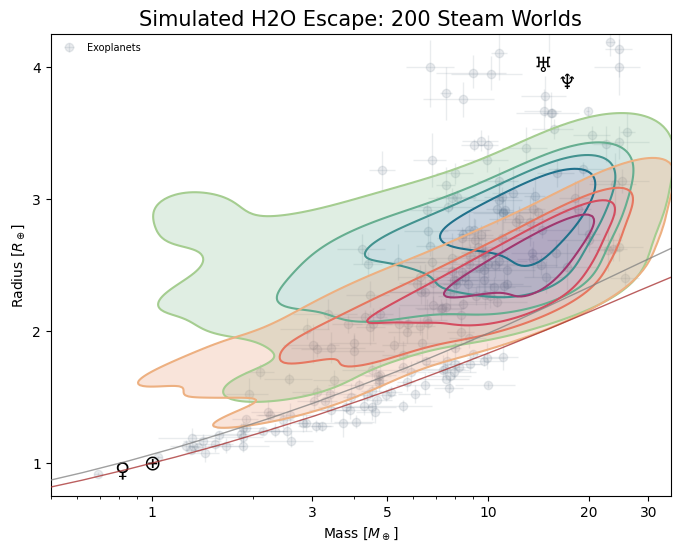

In [11]:
import plot_module as pm
for mt in mdot_type:
    pm.kde(n_planets, mt, catalog='PlanetS', datapath="data/", plotpath="Figures/")

# And that's all! 